In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os

In [2]:
adata = sc.read('data/adata_mouse_brain_aging_MERFISH_imputed.h5ad')

KeyboardInterrupt: 

In [ ]:
adata.raw.X.toarray()

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 2., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
adata.obsm['spatial'] = adata.obsm['spatial_coords']
del adata.obsm['spatial_coords']

In [ ]:
for age in adata.obs['age'].unique():
    for donor_id in adata.obs['donor_id'].unique():
        donor_number = donor_id.split('_')[-1]
        for slice_ in adata.obs['slice'].unique():
            adata_sub = adata[(adata.obs['age'] == age) & (adata.obs['donor_id'] == donor_id) & (adata.obs['slice'] == slice_)]
            # print(age, donor_number, slice_, "cells:", adata_sub.n_obs)
            if adata_sub.n_obs > 0:
                data_path = f'./data/Mouse_brain_MERFISH_imputed/adata{age}_donor_id_{donor_number}_slice_{slice_}.h5ad'
                os.makedirs(os.path.dirname(data_path), exist_ok=True)
                adata_sub.write(data_path)
            del adata_sub

In [31]:
adata_a4_d1_s0 = adata[(adata.obs['age'] == '4wk') & (adata.obs['donor_id'] == 'MsBrainAgingSpatialDonor_1') & (adata.obs['slice'] == '0')]

In [32]:
adata_a4_d1_s0.obsm

AxisArraysView with keys: X_pca, X_spatial_coords, X_umap, spatial

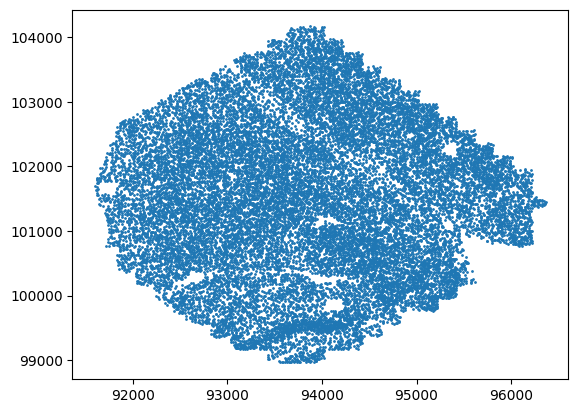

In [34]:
plt.scatter(adata_a4_d1_s0.obsm['spatial'][:, 0], adata_a4_d1_s0.obsm['spatial'][:, 1], s=1, alpha=1)

# MERFISH LPS

In [13]:
adata_lps = sc.read('./data/adata_mouse_brain_aging_MERFISH_LPS_combined.h5ad')
adata_lps

AnnData object with n_obs × n_vars = 345934 × 374
    obs: 'fov', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'age', 'clust_annot', 'slice', 'organism_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'is_primary_data', 'cell_type_annot', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'library', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'feature_is_filtered', 'mean', 'std', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'age_colors', 'batch_condition', 'cell_type_annot_colors', 'citation', 'neighbors', 'pca', 'schema_reference', 'schema_version', 'title', 'umap'
    

In [63]:
adata_lps.obs['donor_id']

Unnamed: 0
326329975246391250729454532282105296430-1    MsBrainAgingSpatialDonor_12
317211872741685298537898172297074752045-1    MsBrainAgingSpatialDonor_12
25688675317913174705357048617732982799-1     MsBrainAgingSpatialDonor_12
106792314379865018792805700736527906581-1    MsBrainAgingSpatialDonor_12
140923259472903153273746499711692469421-1    MsBrainAgingSpatialDonor_12
                                                        ...             
51265139066452430410106312347109313015-1     MsBrainAgingSpatialDonor_19
85442727810141248921780857522084485786-1     MsBrainAgingSpatialDonor_19
54131065294559041555597593609783135577-1     MsBrainAgingSpatialDonor_19
268542215966757918025558614865506509780-1    MsBrainAgingSpatialDonor_19
218460852618192605454556400386723987351-1    MsBrainAgingSpatialDonor_19
Name: donor_id, Length: 345934, dtype: category
Categories (8, object): ['MsBrainAgingSpatialDonor_12', 'MsBrainAgingSpatialDonor_13', 'MsBrainAgingSpatialDonor_14', 'MsBrainAgingSpatial

In [69]:
adata_filt = adata_lps[(adata_lps.obs['age'] == '4wk') & (adata_lps.obs['donor_id'] == 'MsBrainAgingSpatialDonor_14') & (adata_lps.obs['slice'] == '0')]
adata_filt

View of AnnData object with n_obs × n_vars = 22517 × 374
    obs: 'fov', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'age', 'clust_annot', 'slice', 'organism_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'is_primary_data', 'cell_type_annot', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'library', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'feature_is_filtered', 'mean', 'std', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'age_colors', 'batch_condition', 'cell_type_annot_colors', 'citation', 'neighbors', 'pca', 'schema_reference', 'schema_version', 'title', 'uma

In [70]:
map_cell_type_color = {}
for i, x in enumerate(adata_filt.obs['cell_type'].values):
    map_cell_type_color[x] = i

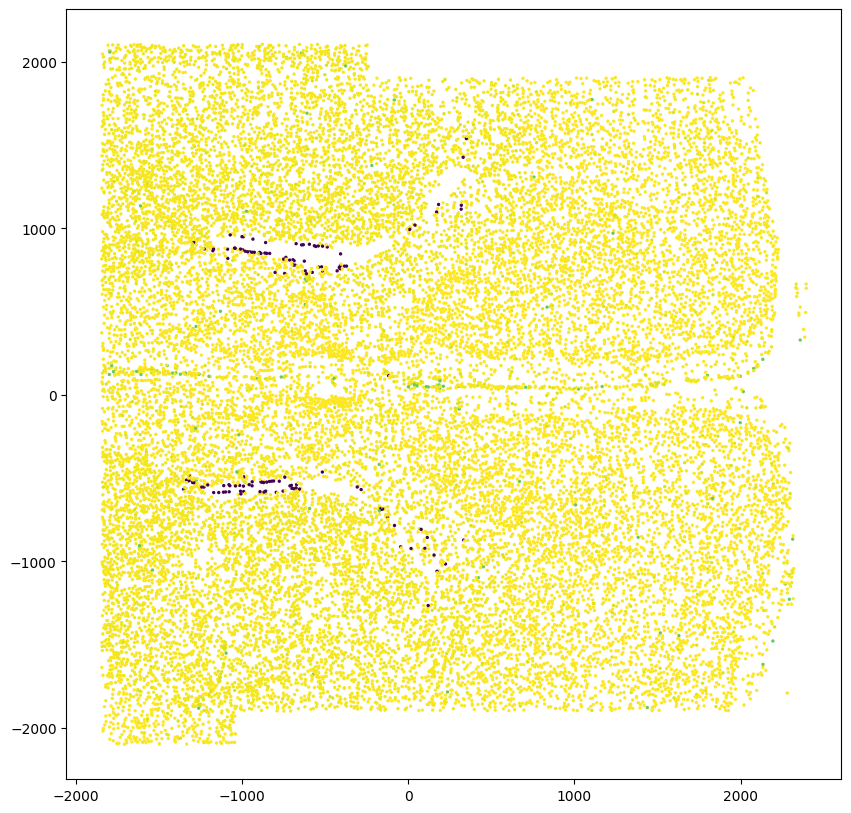

In [71]:
cell_type_enum = list(map(lambda x: map_cell_type_color[x], adata_filt.obs['cell_type']))
plt.figure(figsize=(10, 10))
plt.scatter(adata_filt.obsm['X_spatial_coords'][:, 0], adata_filt.obsm['X_spatial_coords'][:, 1], c=cell_type_enum, s=2)

# Test

In [2]:
adata = sc.read('./data/Mouse_brain_MERFISH/adata4wk_donor_id_1_slice_0.h5ad')
adata

AnnData object with n_obs × n_vars = 21002 × 374
    obs: 'fov', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'age', 'clust_annot', 'slice', 'organism_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'is_primary_data', 'cell_type_annot', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_spatial_coords', 'X_umap', 'spatial'

In [10]:
adata.obs['fov']

296840548544172399853066257548860105346      0
125440231316715565354815908578409815654      0
281867370064380610762953800107398502280      0
317191079211317201281385704641177614171      0
145186441853584143398162181590277934372      0
                                          ... 
130490804126933869257593808487059961710    405
163666373654956068160906734024554294933    405
71955858578521280808006401459391536096     405
40281157344837183772530533557431289864     405
125843388037023310235429375383537945149    405
Name: fov, Length: 21002, dtype: category
Categories (400, object): ['0', '1', '2', '3', ..., '401', '402', '403', '405']

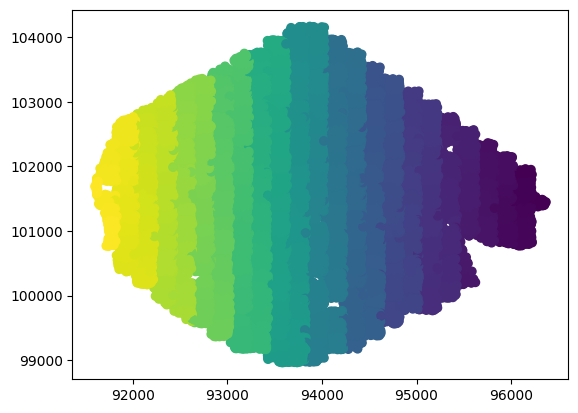

In [12]:
plt.scatter(adata.obsm['spatial'][:, 0], adata.obsm['spatial'][:, 1], c=list(map(lambda x: int(x), adata.obs['fov'])))

In [80]:
adata_d2_s0 = sc.read('./data/Mouse_brain_MERFISH/adata90wk_donor_id_2_slice_0.h5ad')
adata_d2_s1 = sc.read('./data/Mouse_brain_MERFISH/adata90wk_donor_id_2_slice_1.h5ad')

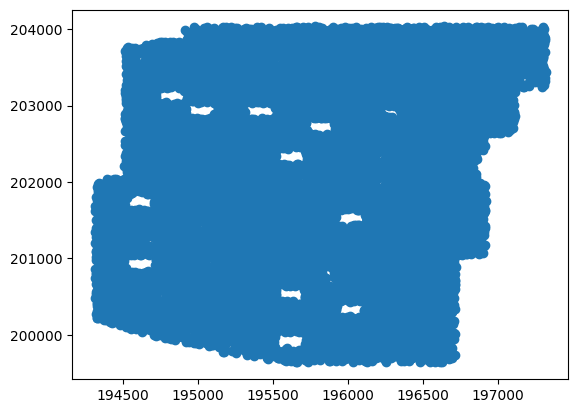

In [83]:
plt.scatter(adata_d2_s0.obsm['spatial'][:, 0], adata_d2_s0.obsm['spatial'][:, 1])

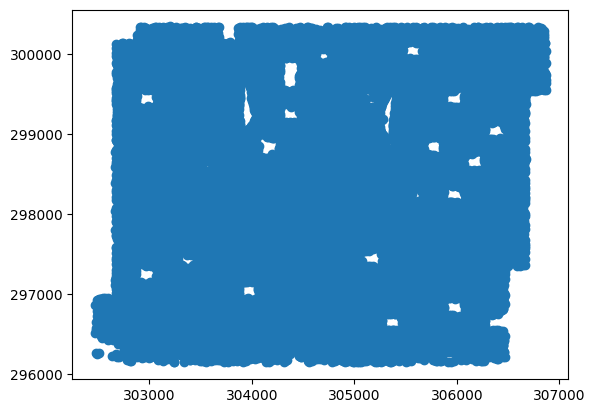

In [84]:
plt.scatter(adata_d2_s1.obsm['spatial'][:, 0], adata_d2_s1.obsm['spatial'][:, 1])

In [1]:
single_samples = [
    './data/Mouse_brain_MERFISH/adata4wk_donor_id_8_slice_1.h5ad',
    './data/Mouse_brain_MERFISH/adata90wk_donor_id_6_slice_0.h5ad',
    './data/Mouse_brain_MERFISH/adata90wk_donor_id_5_slice_0.h5ad',
    './data/Mouse_brain_MERFISH/adata4wk_donor_id_8_slice_2.h5ad',
    './data/Mouse_brain_MERFISH/adata4wk_donor_id_4_slice_1.h5ad',
    './data/Mouse_brain_MERFISH/adata24wk_donor_id_10_slice_2.h5ad',
    './data/Mouse_brain_MERFISH/adata24wk_donor_id_11_slice_2.h5ad',
    './data/Mouse_brain_MERFISH/adata4wk_donor_id_7_slice_2.h5ad',
    './data/Mouse_brain_MERFISH/adata4wk_donor_id_8_slice_0.h5ad',
    './data/Mouse_brain_MERFISH/adata90wk_donor_id_5_slice_1.h5ad',
    './data/Mouse_brain_MERFISH/adata90wk_donor_id_5_slice_2.h5ad',
    './data/Mouse_brain_MERFISH/adata4wk_donor_id_4_slice_2.h5ad',
    './data/Mouse_brain_MERFISH/adata90wk_donor_id_6_slice_2.h5ad',
    './data/Mouse_brain_MERFISH/adata24wk_donor_id_10_slice_1.h5ad',
    './data/Mouse_brain_MERFISH/adata4wk_donor_id_4_slice_0.h5ad',
    './data/Mouse_brain_MERFISH/adata90wk_donor_id_6_slice_1.h5ad'
    './data/Mouse_brain_MERFISH/adata4wk_donor_id_7_slice_0.h5ad',
    './data/Mouse_brain_MERFISH/adata4wk_donor_id_7_slice_1.h5ad',
    './data/Mouse_brain_MERFISH/adata90wk_donor_id_9_slice_0.h5ad',
    './data/Mouse_brain_MERFISH/adata24wk_donor_id_10_slice_0.h5ad',
    './data/Mouse_brain_MERFISH/adata24wk_donor_id_11_slice_0.h5ad',
    './data/Mouse_brain_MERFISH/adata90wk_donor_id_9_slice_1.h5ad',
]